# ShiftProof — Classical Solvers vs. QAOA Empirical Comparison
### Reproducible Scientific Benchmark on Identical Scheduling Problem Instance

---

### Executive Purpose
This notebook performs a reproducible, judge-readable empirical experiment comparing three distinct computational strategies solving the **EXACT SAME** workforce scheduling problem instance:
1. **Exact Classical Reference:** Exhaustive state enumeration to identify the true mathematically optimal feasible assignment.
2. **Greedy Classical Heuristic:** Polynomial-time greedy heuristic prioritizing constrained shifts and lowest available wage.
3. **Quantum Approximate Optimization Algorithm (QAOA):** Variational quantum algorithm evaluated via simulation.

---

### Scientific Integrity & Hardware Disclaimer
- **Simulation Target:** QAOA execution in this notebook is performed via **Qiskit AerSimulator** (statevector/shot-based quantum simulator executing on the local classical CPU).
- **Semantics:** AerSimulator calculates exact quantum statevector evolution and simulates Poisson sampling counts on classical hardware. It is **NOT** physical IBM Quantum superconducting hardware.
- **Honest Reporting:** No claims of "quantum advantage", "quantum speedup", or "quantum superiority" are made. This experiment reports objectively whether QAOA reached the classical reference optimum, produced suboptimal feasible schedules, or sampled infeasible states under variational depth $p=1$.


In [1]:
import sys
import qiskit
import qiskit_aer
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# Ensure project root is in sys.path
_PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

print("=" * 60)
print("COMPUTATIONAL ENVIRONMENT & RUNTIME VERSIONS")
print("=" * 60)
print(f"Python:       {sys.version.split()[0]}")
print(f"Qiskit:       {qiskit.__version__}")
print(f"Qiskit Aer:   {qiskit_aer.__version__}")
print(f"Matplotlib:   {matplotlib.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"NumPy:        {np.__version__}")
print("=" * 60)


COMPUTATIONAL ENVIRONMENT & RUNTIME VERSIONS
Python:       3.14.3
Qiskit:       2.3.1
Qiskit Aer:   0.17.2
Matplotlib:   3.10.8
Pandas:       3.0.2
NumPy:        2.4.4


In [2]:
# Load the deterministic 3x3 workforce scheduling dataset
from app.services.ingestion.file_detector import detect_file_type
from app.services.ingestion.structured_parser import parse_structured_file
from app.services.ingestion.normalizer import normalize_dataset

dataset_file = _PROJECT_ROOT / "data" / "sample" / "workforce_schedule_3x3.csv"
if not dataset_file.exists():
    raise FileNotFoundError(f"Required benchmark dataset not found: {dataset_file}")

file_bytes = dataset_file.read_bytes()
file_type, file_cat = detect_file_type(dataset_file.name, file_bytes)
parsed = parse_structured_file(file_bytes, dataset_file.name, file_type)
df_raw = parsed.df

# Normalize to canonical schema
mapping = {
    'worker': 'employee_name',
    'shift': 'shift_title',
    'cost': 'hourly_wage',
    'availability': 'is_available'
}
norm_res = normalize_dataset(df_raw, mapping)
df_canonical = norm_res.df_normalized

print("=" * 60)
print("BENCHMARK WORKFORCE DATASET (3 Workers x 3 Shifts)")
print("=" * 60)
cols_display = ["worker_id", "worker_name", "shift_id", "shift_name", "shift_type", "assignment_cost", "is_eligible", "is_available"]
print(df_canonical[cols_display].to_string(index=False))


BENCHMARK WORKFORCE DATASET (3 Workers x 3 Shifts)
    worker_id   worker_name        shift_id      shift_name shift_type  assignment_cost  is_eligible  is_available
Elena_Rostova Elena Rostova       Day_Shift       Day Shift    Morning             42.0            1             1
Elena_Rostova Elena Rostova   Evening_Shift   Evening Shift  Afternoon             50.0            1             1
Elena_Rostova Elena Rostova Night_ICU_Shift Night ICU Shift      Night             65.0            1             1
  Marcus_Chen   Marcus Chen       Day_Shift       Day Shift    Morning             30.0            1             1
  Marcus_Chen   Marcus Chen   Evening_Shift   Evening Shift  Afternoon             35.0            1             1
  Marcus_Chen   Marcus Chen Night_ICU_Shift Night ICU Shift      Night            999.0            0             0
 Sarah_Miller  Sarah Miller       Day_Shift       Day Shift    Morning             38.0            1             1
 Sarah_Miller  Sarah Miller  

In [3]:
# Transform canonical records into ShiftProof frozen mathematical Instance
from app.services.scheduling_service import normalized_to_instance, compute_dataframe_fingerprint

instance = normalized_to_instance(
    norm_res=norm_res,
    instance_id="inst_classical_vs_qaoa_3x3",
    seed=42,
)

dataset_fingerprint = compute_dataframe_fingerprint(df_canonical)

print("=" * 60)
print("MATHEMATICAL PROBLEM INSTANCE SPECIFICATION")
print("=" * 60)
print(f"Instance ID:               {instance.instance_id}")
print(f"Dataset SHA-256:           {dataset_fingerprint}")
print(f"Workers (n_workers):       {instance.n_workers}")
print(f"Shifts (n_shifts):         {instance.n_shifts}")
print(f"All Pair Combinations:     {instance.n_workers * instance.n_shifts}")
print(f"Eligible Pairs:            {instance.n_vars}")
print(f"Pruned Ineligible Pairs:   {instance.n_workers * instance.n_shifts - instance.n_vars}")
print(f"Binary Decision Variables: {instance.n_vars}")
print(f"Target Qubits:             {instance.n_vars}")

print("\nCost Matrix c_{w,s}:")
print(instance.cost_matrix)

print("\nEligibility Matrix e_{w,s}:")
print(instance.eligibility)


MATHEMATICAL PROBLEM INSTANCE SPECIFICATION
Instance ID:               inst_classical_vs_qaoa_3x3
Dataset SHA-256:           fp_7654cf830d0e0699
Workers (n_workers):       3
Shifts (n_shifts):         3
All Pair Combinations:     9
Eligible Pairs:            7
Pruned Ineligible Pairs:   2
Binary Decision Variables: 7
Target Qubits:             7

Cost Matrix c_{w,s}:
[[ 42.  50.  65.]
 [ 30.  35. 999.]
 [ 38.  40. 999.]]

Eligibility Matrix e_{w,s}:
[[ True  True  True]
 [ True  True False]
 [ True  True False]]


In [4]:
# Register 1:1 bidirectional mapping between binary decision variables and qubits
print("=" * 60)
print("DECISION VARIABLE <-> QUBIT REGISTRATION")
print("=" * 60)

var_rows = []
for q in range(instance.n_vars):
    w, s = instance.get_var(q)
    cost = instance.get_cost(w, s)
    var_rows.append({
        "Qubit q": q,
        "Variable x_{w,s}": f"x_{{{w},{s}}}",
        "Worker ID": f"W{w}",
        "Shift ID": f"S{s}",
        "Hourly Cost ($)": f"${cost:.2f}",
        "Eligible": instance.is_eligible(w, s)
    })

df_var_map = pd.DataFrame(var_rows)
print(df_var_map.to_string(index=False))

# Assert mathematical invariant: exactly 1 qubit per decision variable
assert instance.n_vars == len(instance.var_to_qubit), "Variable-to-qubit registration mismatch!"
print(f"\n✓ Verified 1:1 mapping: {instance.n_vars} variables <==> {instance.n_vars} qubits")


DECISION VARIABLE <-> QUBIT REGISTRATION
 Qubit q Variable x_{w,s} Worker ID Shift ID Hourly Cost ($)  Eligible
       0          x_{0,0}        W0       S0          $42.00      True
       1          x_{0,1}        W0       S1          $50.00      True
       2          x_{0,2}        W0       S2          $65.00      True
       3          x_{1,0}        W1       S0          $30.00      True
       4          x_{1,1}        W1       S1          $35.00      True
       5          x_{2,0}        W2       S0          $38.00      True
       6          x_{2,1}        W2       S1          $40.00      True

✓ Verified 1:1 mapping: 7 variables <==> 7 qubits


In [5]:
# Construct Quadratic Unconstrained Binary Optimization (QUBO) model
from src.quantum import build_qubo

qubo = build_qubo(instance)

print("=" * 60)
print("QUBO PROBLEM FORMULATION")
print("=" * 60)
print(f"Objective Mode:            Cost Minimization with Exact Constraints")
print(f"Constant Energy Offset q0: {qubo.q0:.4f}")
print(f"Penalty Multiplier A:      {qubo.A:.2f} (Shift Coverage)")
print(f"Penalty Multiplier B:      {qubo.B:.2f} (Worker Capacity)")
print(f"Linear Vector a (size {len(qubo.a)}):")
print(qubo.a)

print(f"\nQuadratic Couplings Matrix b (shape {qubo.b.shape}):")
print(f"Active Couplings:          {np.count_nonzero(qubo.b)} / {qubo.b.size}")
print(qubo.b)


QUBO PROBLEM FORMULATION
Objective Mode:            Cost Minimization with Exact Constraints
Constant Energy Offset q0: 408.0000
Penalty Multiplier A:      136.00 (Shift Coverage)
Penalty Multiplier B:      136.00 (Worker Capacity)
Linear Vector a (size 7):
[ -94.  -86.  -71. -106. -101.  -98.  -96.]

Quadratic Couplings Matrix b (shape (7, 7)):
Active Couplings:          11 / 49
[[  0. 136. 136. 272.   0. 272.   0.]
 [  0.   0. 136.   0. 272.   0. 272.]
 [  0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0. 136. 272.   0.]
 [  0.   0.   0.   0.   0.   0. 272.]
 [  0.   0.   0.   0.   0.   0. 136.]
 [  0.   0.   0.   0.   0.   0.   0.]]


In [6]:
# Map QUBO binary variables x in {0, 1} to Ising spin variables z in {+1, -1}
from src.quantum import qubo_to_ising

ising = qubo_to_ising(qubo)

print("=" * 60)
print("ISING SPIN HAMILTONIAN: H = offset + sum h_i Z_i + sum J_ij Z_i Z_j")
print("=" * 60)
print(f"Offset Energy:             {ising.offset:.4f}")
print(f"Single-Qubit Fields (h):   {ising.h}")
print(f"Two-Qubit Interactions (J): {np.count_nonzero(ising.J)} active couplings")
print(f"Ising Coupling Matrix J (shape {ising.J.shape}):")
print(ising.J)


ISING SPIN HAMILTONIAN: H = offset + sum h_i Z_i + sum J_ij Z_i Z_j
Offset Energy:             660.0000
Single-Qubit Fields (h):   [-157.  -161.   -32.5 -117.  -119.5 -121.  -122. ]
Two-Qubit Interactions (J): 11 active couplings
Ising Coupling Matrix J (shape (7, 7)):
[[ 0. 34. 34. 68.  0. 68.  0.]
 [ 0.  0. 34.  0. 68.  0. 68.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 34. 68.  0.]
 [ 0.  0.  0.  0.  0.  0. 68.]
 [ 0.  0.  0.  0.  0.  0. 34.]
 [ 0.  0.  0.  0.  0.  0.  0.]]


In [7]:
# Exhaustively verify Q(x) == H(z(x)) across ALL 2^n basis states
from src.validation import validate_qubo_ising_equivalence

equiv_checks = validate_qubo_ising_equivalence(instance)

print("=" * 60)
print("QUBO <-> ISING ENERGY EQUIVALENCE VERIFICATION")
print("=" * 60)
for r in equiv_checks:
    status = "✓ PASS" if r.passed else "✗ FAIL"
    print(f"  [{status}] {r.check_name}: {r.message}")
    assert r.passed, f"Validation failure: {r.message}"

print(f"\n✓ Verified 100% mathematical energy equivalence across all {2**instance.n_vars} basis states.")


QUBO <-> ISING ENERGY EQUIVALENCE VERIFICATION
  [✓ PASS] QUBO-Ising equivalence: All 128 bitstrings match (max diff: 0.00e+00)

✓ Verified 100% mathematical energy equivalence across all 128 basis states.


In [8]:
# 1. EXACT CLASSICAL SOLVER (Exhaustive Enumeration)
import time
from src.classical import solve_exact
from src.model import check_constraints, assignment_cost

t0_exact = time.perf_counter()
exact_result = solve_exact(instance)
exact_runtime = time.perf_counter() - t0_exact

# Independent verification of returned assignment
exact_feasible, exact_violations = check_constraints(instance, exact_result.optimal_assignment)
exact_recomputed_cost = assignment_cost(instance, exact_result.optimal_assignment)

print("=" * 60)
print("EXACT CLASSICAL REFERENCE (Ground Truth Optimum)")
print("=" * 60)
print(f"Solver Method:             Exhaustive Search (solve_exact)")
print(f"Feasibility Status:        {exact_result.feasible} (Audit: {exact_feasible})")
print(f"Optimal Total Cost:        ${exact_result.optimal_cost:.2f}")
print(f"Optimal Assignment:        {exact_result.optimal_assignment}")
print(f"States Evaluated:          {2**instance.n_vars}")
print(f"Execution Runtime:         {exact_runtime * 1000:.4f} ms")
print(f"Constraint Violations:     {exact_violations}")

assert exact_feasible, "Exact solver returned an infeasible assignment!"
assert exact_result.optimal_cost == exact_recomputed_cost, "Exact cost mismatch!"
print("\n✓ EXACT CLASSICAL REFERENCE VERIFIED: This is the mathematically guaranteed global optimum.")


EXACT CLASSICAL REFERENCE (Ground Truth Optimum)
Solver Method:             Exhaustive Search (solve_exact)
Feasibility Status:        True (Audit: True)
Optimal Total Cost:        $135.00
Optimal Assignment:        {(0, 2): 1, (1, 0): 1, (2, 1): 1}
States Evaluated:          128
Execution Runtime:         0.8302 ms
Constraint Violations:     {'shift_coverage': {0: True, 1: True, 2: True}, 'worker_at_most_one': {0: True, 1: True, 2: True}, 'eligibility': {(0, 2): True, (1, 0): True, (2, 1): True}}

✓ EXACT CLASSICAL REFERENCE VERIFIED: This is the mathematically guaranteed global optimum.


In [9]:
# 2. GREEDY CLASSICAL HEURISTIC
from src.classical import solve_greedy

t0_greedy = time.perf_counter()
greedy_result = solve_greedy(instance)
greedy_runtime = time.perf_counter() - t0_greedy

# Independent verification of greedy solution
greedy_feasible, greedy_violations = check_constraints(instance, greedy_result.optimal_assignment)
greedy_cost = greedy_result.optimal_cost

# Compute optimality gaps relative to exact reference
exact_cost = exact_result.optimal_cost
greedy_abs_gap = greedy_cost - exact_cost if (greedy_cost is not None and exact_cost is not None) else None
greedy_rel_gap = (greedy_abs_gap / exact_cost) if (greedy_abs_gap is not None and exact_cost > 0) else 0.0

print("=" * 60)
print("GREEDY CLASSICAL HEURISTIC BASELINE")
print("=" * 60)
print(f"Solver Method:             Priority-Based Greedy (solve_greedy)")
print(f"Feasibility Status:        {greedy_result.feasible} (Audit: {greedy_feasible})")
print(f"Greedy Total Cost:         ${greedy_cost:.2f}" if greedy_cost is not None else "Greedy Cost: None")
print(f"Greedy Assignment:         {greedy_result.optimal_assignment}")
print(f"Absolute Gap from Exact:   ${greedy_abs_gap:.2f}" if greedy_abs_gap is not None else "N/A")
print(f"Relative Gap from Exact:   {greedy_rel_gap * 100:.2f}%" if greedy_abs_gap is not None else "N/A")
print(f"Execution Runtime:         {greedy_runtime * 1000:.4f} ms")
print(f"Constraint Violations:     {greedy_violations}")


GREEDY CLASSICAL HEURISTIC BASELINE
Solver Method:             Priority-Based Greedy (solve_greedy)
Feasibility Status:        True (Audit: True)
Greedy Total Cost:         $135.00
Greedy Assignment:         {(0, 2): 1, (1, 0): 1, (2, 1): 1}
Absolute Gap from Exact:   $0.00
Relative Gap from Exact:   0.00%
Execution Runtime:         0.0482 ms
Constraint Violations:     {'shift_coverage': {0: True, 1: True, 2: True}, 'worker_at_most_one': {0: True, 1: True, 2: True}, 'eligibility': {(0, 2): True, (1, 0): True, (2, 1): True}}


In [10]:
# 3. BUILD ACTUAL QISKIT QAOA CIRCUIT (p=1)
from src.quantum import build_qaoa_circuit

p_layers = 1
qc, gamma_params, beta_params = build_qaoa_circuit(ising, p=p_layers)

print("=" * 60)
print("ACTUAL QISKIT QAOA CIRCUIT (Ingested Instance)")
print("=" * 60)
print(f"Target Backend:            Qiskit AerSimulator")
print(f"Circuit Qubits:            {qc.num_qubits}")
print(f"Classical Bits:            {qc.num_clbits}")
print(f"QAOA Variational Depth p:  {p_layers}")
print(f"Circuit Depth:             {qc.depth()}")
print(f"Total Gate Count:          {qc.size()}")
print(f"Two-Qubit Entangling CX:   {qc.count_ops().get('cx', 0)}")
print(f"Single-Qubit Rotations:    RZ={qc.count_ops().get('rz', 0)}, RX={qc.count_ops().get('rx', 0)}, H={qc.count_ops().get('h', 0)}")
print(f"Measurement Operators:     {qc.count_ops().get('measure', 0)}")

# Strict invariant check
assert qc.num_qubits == instance.n_vars, "Qubit count must equal instance decision variable count!"

print("\nTEXT CIRCUIT DIAGRAM:")
print(qc.draw("text", fold=-1))


ACTUAL QISKIT QAOA CIRCUIT (Ingested Instance)
Target Backend:            Qiskit AerSimulator
Circuit Qubits:            7
Classical Bits:            7
QAOA Variational Depth p:  1
Circuit Depth:             25
Total Gate Count:          61
Two-Qubit Entangling CX:   22
Single-Qubit Rotations:    RZ=18, RX=7, H=7
Measurement Operators:     7

TEXT CIRCUIT DIAGRAM:
        ┌───┐┌────────────────┐                                                                                                                                    ┌───────────┐                                                                                                                                             ░ ┌─┐                  
   q_0: ┤ H ├┤ Rz((-314)*γ_0) ├──■──────────────────■────■──────────────────■────■─────────────────────────────────■─────────■──────────────────────────────────■──┤ Rx(2*β_0) ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

GRAPHICAL QISKIT QAOA QUANTUM CIRCUIT


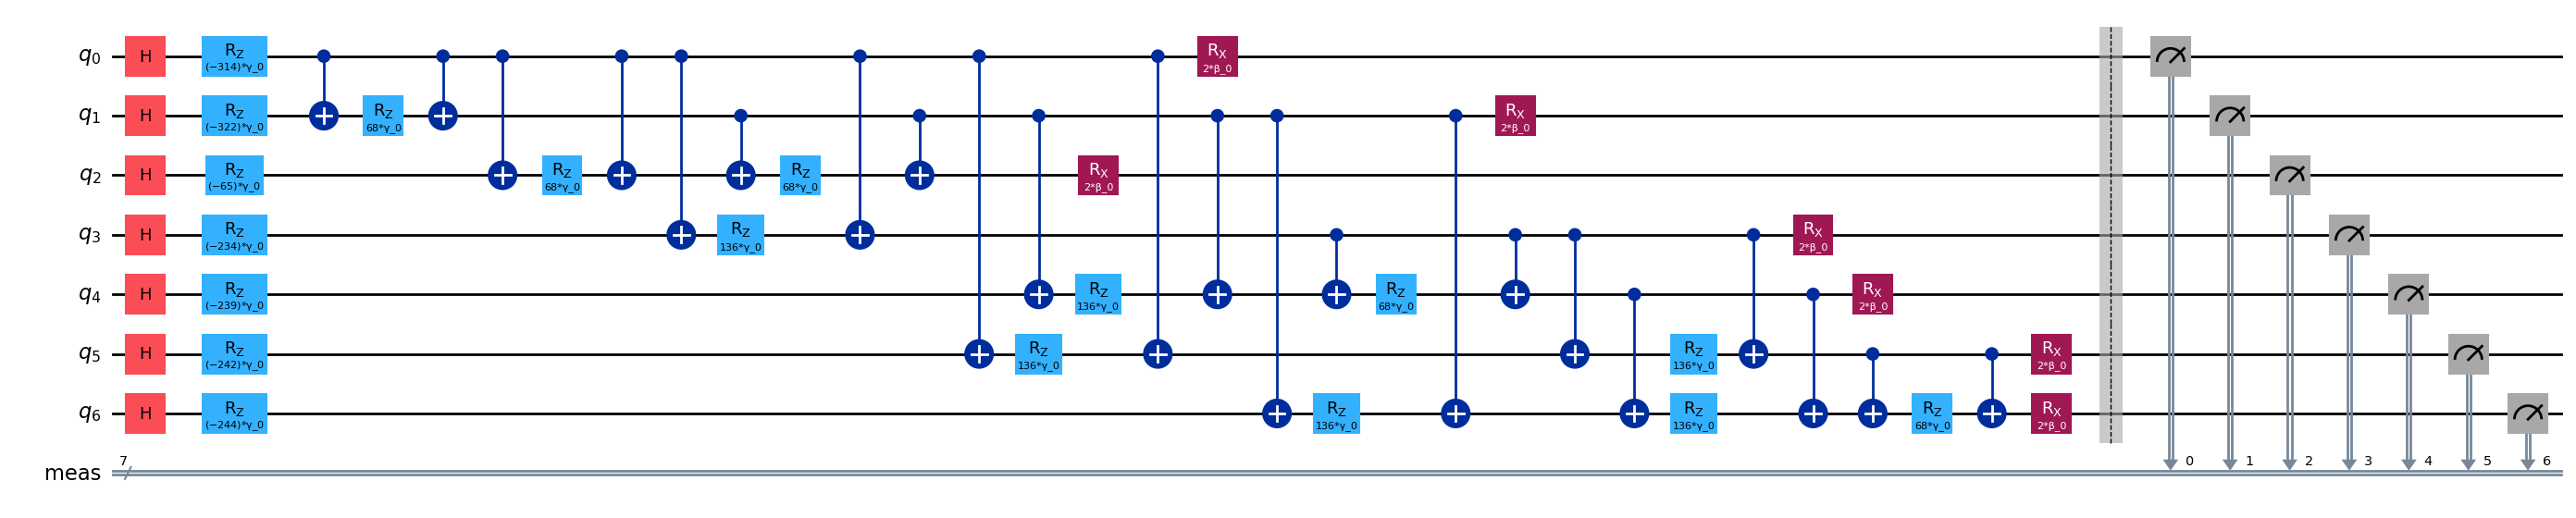

In [11]:
# Render graphical Matplotlib representation of the ACTUAL QuantumCircuit
from IPython.display import display

print("=" * 60)
print("GRAPHICAL QISKIT QAOA QUANTUM CIRCUIT")
print("=" * 60)
display(qc.draw("mpl", fold=-1))


In [12]:
# Execute QAOA simulation on Qiskit AerSimulator
from src.quantum import run_qaoa_p1

shots = 1024
maxiter = 50
seed = 42

print(f"Executing QAOA on Qiskit AerSimulator ({shots} shots, seed={seed}) ...")
qaoa_result = run_qaoa_p1(
    instance=instance,
    shots=shots,
    maxiter=maxiter,
    seed=seed,
)

print("=" * 60)
print("QISKIT AERSIMULATOR SIMULATION OUTPUT")
print("=" * 60)
print(f"Backend Target:            Qiskit AerSimulator")
print(f"Simulation Platform:       Classical CPU (local workstation)")
print(f"Shots Sampled:             {qaoa_result.shots}")
print(f"Variational Depth (p):     {qaoa_result.p}")
print(f"Classical Optimizer:       {qaoa_result.optimizer} (maxiter={qaoa_result.maxiter})")
print(f"Optimizer Evaluations:     {qaoa_result.optimizer_evaluations}")
print(f"Optimal Gamma (γ_0):       {qaoa_result.optimal_params[0]:.6f}")
print(f"Optimal Beta (β_0):        {qaoa_result.optimal_params[1]:.6f}")
print(f"Optimal Expectation:       {qaoa_result.optimal_energy:.4f}")
print(f"Simulation Runtime:        {qaoa_result.runtime_seconds:.4f} s")


Executing QAOA on Qiskit AerSimulator (1024 shots, seed=42) ...


QISKIT AERSIMULATOR SIMULATION OUTPUT
Backend Target:            Qiskit AerSimulator
Simulation Platform:       Classical CPU (local workstation)
Shots Sampled:             1024
Variational Depth (p):     1
Classical Optimizer:       COBYLA (maxiter=50)
Optimizer Evaluations:     28
Optimal Gamma (γ_0):       0.136830
Optimal Beta (β_0):        0.088425
Optimal Expectation:       571.5430
Simulation Runtime:        0.5398 s


In [13]:
# Tabulate raw quantum measurement distribution from AerSimulator
counts = qaoa_result.samples

measurement_records = []
for bs, cnt in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    measurement_records.append({
        "Bitstring": bs,
        "Shots": cnt,
        "Probability": cnt / shots,
    })

df_counts = pd.DataFrame(measurement_records)

print("=" * 60)
print(f"MEASUREMENT COUNTS DISTRIBUTION ({len(df_counts)} unique basis states)")
print("=" * 60)
print("Top 15 Most Frequently Sampled Basis States:")
print(df_counts.head(15).to_string(index=False))


MEASUREMENT COUNTS DISTRIBUTION (127 unique basis states)
Top 15 Most Frequently Sampled Basis States:
Bitstring  Shots  Probability
  1000110     18     0.017578
  0101110     18     0.017578
  0100110     18     0.017578
  0000111     18     0.017578
  0000100     17     0.016602
  0001100     17     0.016602
  0001110     17     0.016602
  0010000     17     0.016602
  1000111     15     0.014648
  0000110     15     0.014648
  0100010     14     0.013672
  1000000     14     0.013672
  0001000     14     0.013672
  0010100     13     0.012695
  0010010     13     0.012695


In [14]:
# Independently audit every sampled quantum state without trusting raw QAOA output
from src.model import decode_bitstring

audited_states = []
feasible_samples_count = 0
best_qaoa_feasible_cost = float('inf')
best_qaoa_assignment = None
optimal_count = 0

for bs, count in counts.items():
    assignment = decode_bitstring(instance, bs)
    is_feasible, violations = check_constraints(instance, assignment)
    cost = assignment_cost(instance, assignment) if is_feasible else None
    
    if is_feasible:
        feasible_samples_count += count
        if cost < best_qaoa_feasible_cost:
            best_qaoa_feasible_cost = cost
            best_qaoa_assignment = assignment.copy()
        if exact_cost is not None and abs(cost - exact_cost) < 1e-6:
            optimal_count += count

    audited_states.append({
        "bitstring": bs,
        "count": count,
        "probability": count / shots,
        "feasible": is_feasible,
        "cost": cost,
        "violations": ", ".join(violations) if violations else "None",
        "assignment": assignment
    })

df_audited = pd.DataFrame(audited_states).sort_values("count", ascending=False)

# Compute rigorous QAOA performance metrics
qaoa_feasibility_rate = feasible_samples_count / shots
qaoa_optimal_probability = optimal_count / shots

if feasible_samples_count > 0:
    qaoa_abs_gap = best_qaoa_feasible_cost - exact_cost
    qaoa_rel_gap = (qaoa_abs_gap / exact_cost) if exact_cost > 0 else 0.0
else:
    best_qaoa_feasible_cost = None
    qaoa_abs_gap = None
    qaoa_rel_gap = None

print("=" * 60)
print("INDEPENDENT QUANTUM STATE VERIFICATION AUDIT")
print("=" * 60)
print(f"Total Shots Evaluated:         {shots}")
print(f"Feasible Shots Observed:       {feasible_samples_count} / {shots}")
print(f"QAOA Feasibility Rate:         {qaoa_feasibility_rate * 100:.2f}%")
print(f"Optimal Solution Shots:        {optimal_count} / {shots}")
print(f"Optimal Solution Probability:  {qaoa_optimal_probability * 100:.2f}%")

if best_qaoa_feasible_cost is not None:
    print(f"Best Feasible QAOA Cost:       ${best_qaoa_feasible_cost:.2f}")
    print(f"Absolute Gap from Exact:       ${qaoa_abs_gap:.2f}")
    print(f"Relative Gap from Exact:       {qaoa_rel_gap * 100:.2f}%")
    print(f"Best Feasible Assignment:      {best_qaoa_assignment}")
else:
    print("No feasible quantum sample observed.")

print("\nSample of Top 10 Audited States:")
preview_cols = ["bitstring", "count", "probability", "feasible", "cost", "violations"]
print(df_audited[preview_cols].head(10).to_string(index=False))


INDEPENDENT QUANTUM STATE VERIFICATION AUDIT
Total Shots Evaluated:         1024
Feasible Shots Observed:       16 / 1024
QAOA Feasibility Rate:         1.56%
Optimal Solution Shots:        7 / 1024
Optimal Solution Probability:  0.68%
Best Feasible QAOA Cost:       $135.00
Absolute Gap from Exact:       $0.00
Relative Gap from Exact:       0.00%
Best Feasible Assignment:      {(0, 2): 1, (1, 0): 1, (2, 1): 1}

Sample of Top 10 Audited States:
bitstring  count  probability  feasible  cost                                      violations
  0101110     18     0.017578     False   NaN shift_coverage, worker_at_most_one, eligibility
  1000110     18     0.017578     False   NaN shift_coverage, worker_at_most_one, eligibility
  0000111     18     0.017578     False   NaN shift_coverage, worker_at_most_one, eligibility
  0100110     18     0.017578     False   NaN shift_coverage, worker_at_most_one, eligibility
  0001110     17     0.016602     False   NaN shift_coverage, worker_at_most_one, 

In [15]:
# Side-by-side final assignment schedule comparison across all three solvers
schedule_rows = []

shift_names = {0: "Day Shift (S0)", 1: "Evening Shift (S1)", 2: "Night ICU Shift (S2)"}
worker_names = {0: "Elena Rostova (W0)", 1: "Marcus Chen (W1)", 2: "Sarah Miller (W2)"}

for s in range(instance.n_shifts):
    # Exact assigned worker
    w_exact = [w for w in range(instance.n_workers) if exact_result.optimal_assignment.get((w, s), 0) == 1]
    w_exact_str = worker_names[w_exact[0]] if w_exact else "Unassigned"
    c_exact = instance.get_cost(w_exact[0], s) if w_exact else 0.0
    
    # Greedy assigned worker
    w_greedy = [w for w in range(instance.n_workers) if greedy_result.optimal_assignment.get((w, s), 0) == 1]
    w_greedy_str = worker_names[w_greedy[0]] if w_greedy else "Unassigned"
    c_greedy = instance.get_cost(w_greedy[0], s) if w_greedy else 0.0
    
    # QAOA best feasible assigned worker
    if best_qaoa_assignment:
        w_qaoa = [w for w in range(instance.n_workers) if best_qaoa_assignment.get((w, s), 0) == 1]
        w_qaoa_str = worker_names[w_qaoa[0]] if w_qaoa else "Unassigned"
        c_qaoa = instance.get_cost(w_qaoa[0], s) if w_qaoa else 0.0
    else:
        w_qaoa_str = "None"
        c_qaoa = 0.0

    schedule_rows.append({
        "Shift": shift_names[s],
        "Exact Assigned Worker": f"{w_exact_str} (${c_exact:.0f})",
        "Greedy Assigned Worker": f"{w_greedy_str} (${c_greedy:.0f})",
        "QAOA Assigned Worker": f"{w_qaoa_str} (${c_qaoa:.0f})",
        "Shift Constraint": "Satisfied (1 worker/shift)"
    })

df_schedule = pd.DataFrame(schedule_rows)
print("=" * 60)
print("FINAL ROSTER ASSIGNMENT SCHEDULE COMPARISON")
print("=" * 60)
print(df_schedule.to_string(index=False))


FINAL ROSTER ASSIGNMENT SCHEDULE COMPARISON
               Shift    Exact Assigned Worker   Greedy Assigned Worker     QAOA Assigned Worker           Shift Constraint
      Day Shift (S0)   Marcus Chen (W1) ($30)   Marcus Chen (W1) ($30)   Marcus Chen (W1) ($30) Satisfied (1 worker/shift)
  Evening Shift (S1)  Sarah Miller (W2) ($40)  Sarah Miller (W2) ($40)  Sarah Miller (W2) ($40) Satisfied (1 worker/shift)
Night ICU Shift (S2) Elena Rostova (W0) ($65) Elena Rostova (W0) ($65) Elena Rostova (W0) ($65) Satisfied (1 worker/shift)


In [16]:
# Final comprehensive comparison table
comparison_records = [
    {
        "Method": "Exact Classical Reference",
        "Feasible": "YES" if exact_result.feasible else "NO",
        "Cost ($)": f"${exact_result.optimal_cost:.2f}",
        "Absolute Gap ($)": "$0.00 (Reference)",
        "Relative Gap (%)": "0.00%",
        "Runtime": f"{exact_runtime * 1000:.3f} ms",
        "Optimality Guarantee": "Mathematically Proven Global Optimum"
    },
    {
        "Method": "Greedy Classical Heuristic",
        "Feasible": "YES" if greedy_result.feasible else "NO",
        "Cost ($)": f"${greedy_cost:.2f}" if greedy_cost is not None else "N/A",
        "Absolute Gap ($)": f"${greedy_abs_gap:.2f}" if greedy_abs_gap is not None else "N/A",
        "Relative Gap (%)": f"{greedy_rel_gap * 100:.2f}%" if greedy_abs_gap is not None else "N/A",
        "Runtime": f"{greedy_runtime * 1000:.3f} ms",
        "Optimality Guarantee": "None (Polynomial Heuristic)"
    },
    {
        "Method": "QAOA (AerSimulator Best Sample)",
        "Feasible": "YES" if best_qaoa_feasible_cost is not None else "NO",
        "Cost ($)": f"${best_qaoa_feasible_cost:.2f}" if best_qaoa_feasible_cost is not None else "No Feasible Sample",
        "Absolute Gap ($)": f"${qaoa_abs_gap:.2f}" if qaoa_abs_gap is not None else "N/A",
        "Relative Gap (%)": f"{qaoa_rel_gap * 100:.2f}%" if qaoa_abs_gap is not None else "N/A",
        "Runtime": f"{qaoa_result.runtime_seconds:.3f} s",
        "Optimality Guarantee": f"Probabilistic ({qaoa_optimal_probability * 100:.2f}% optimal sampling)"
    }
]

df_comparison = pd.DataFrame(comparison_records)

print("=" * 60)
print("CLASSICAL SOLVERS vs. QAOA EMPIRICAL BENCHMARK")
print("=" * 60)
print(df_comparison.to_string(index=False))

print(f"\nAdditional Quantum Sampling Telemetry:")
print(f"  • QAOA Feasibility Rate:               {qaoa_feasibility_rate * 100:.2f}% ({feasible_samples_count}/{shots} shots)")
print(f"  • QAOA Optimal Solution Probability:   {qaoa_optimal_probability * 100:.2f}% ({optimal_count}/{shots} shots)")


CLASSICAL SOLVERS vs. QAOA EMPIRICAL BENCHMARK
                         Method Feasible Cost ($)  Absolute Gap ($) Relative Gap (%)  Runtime                   Optimality Guarantee
      Exact Classical Reference      YES  $135.00 $0.00 (Reference)            0.00% 0.830 ms   Mathematically Proven Global Optimum
     Greedy Classical Heuristic      YES  $135.00             $0.00            0.00% 0.048 ms            None (Polynomial Heuristic)
QAOA (AerSimulator Best Sample)      YES  $135.00             $0.00            0.00%  0.540 s Probabilistic (0.68% optimal sampling)

Additional Quantum Sampling Telemetry:
  • QAOA Feasibility Rate:               1.56% (16/1024 shots)
  • QAOA Optimal Solution Probability:   0.68% (7/1024 shots)


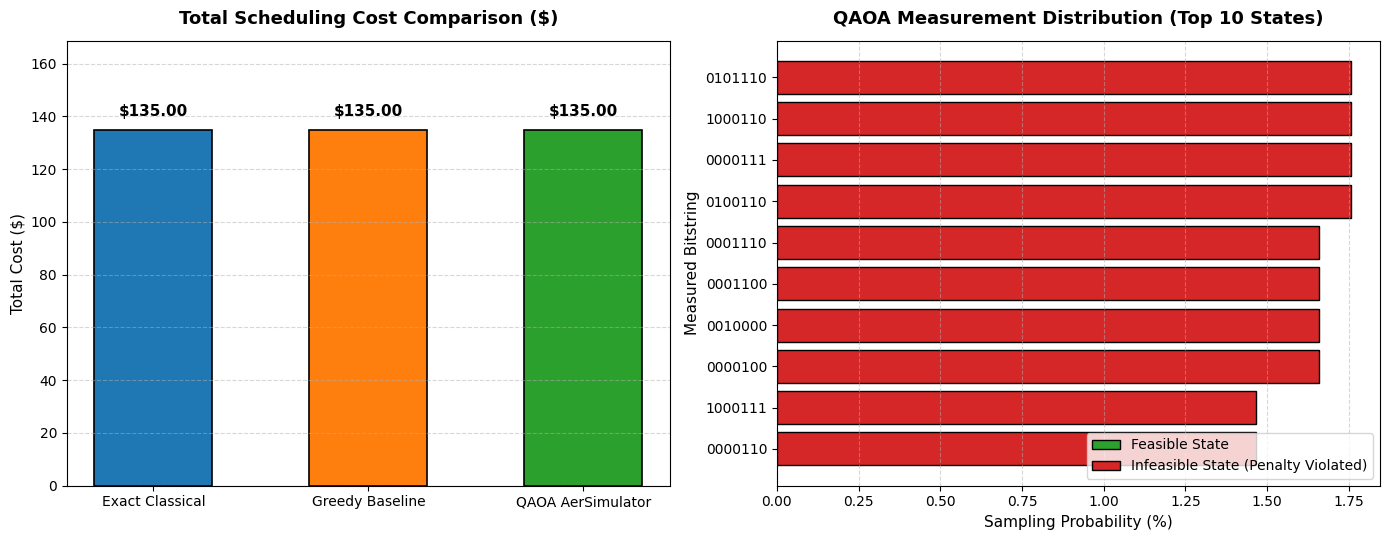

In [17]:
# Matplotlib Visualizations: Cost Comparison & Measurement Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot A: Cost Comparison
methods = ["Exact Classical", "Greedy Baseline", "QAOA AerSimulator"]
costs = [
    exact_result.optimal_cost,
    greedy_cost if greedy_cost is not None else 0,
    best_qaoa_feasible_cost if best_qaoa_feasible_cost is not None else 0
]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

bars = ax1.bar(methods, costs, color=colors, width=0.55, edgecolor="black", linewidth=1.2)
ax1.set_title("Total Scheduling Cost Comparison ($)", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Total Cost ($)", fontsize=11)
ax1.set_ylim(0, max(costs) * 1.25)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

for bar, cost in zip(bars, costs):
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, yval + (max(costs) * 0.03), f"${cost:.2f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")

# Plot B: QAOA Top 10 Measured States & Feasibility
top10 = df_audited.head(10).copy()
state_colors = ["#2ca02c" if f else "#d62728" for f in top10["feasible"]]

bars2 = ax2.barh(top10["bitstring"], top10["probability"] * 100, color=state_colors, edgecolor="black", linewidth=1.0)
ax2.set_title("QAOA Measurement Distribution (Top 10 States)", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Sampling Probability (%)", fontsize=11)
ax2.set_ylabel("Measured Bitstring", fontsize=11)
ax2.invert_yaxis()  # Highest frequency on top
ax2.grid(axis="x", linestyle="--", alpha=0.5)

# Custom legend for feasibility
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ca02c", edgecolor="black", label="Feasible State"),
    Patch(facecolor="#d62728", edgecolor="black", label="Infeasible State (Penalty Violated)")
]
ax2.legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()


In [18]:
# Provenance & Reproducibility Ledger
provenance_ledger = {
    "Dataset File":                dataset_file.name,
    "Dataset Fingerprint":         dataset_fingerprint,
    "Instance Identifier":         instance.instance_id,
    "Random Seed":                 seed,
    "AerSimulator Shots":          shots,
    "QAOA Layers (p)":             p_layers,
    "Circuit Qubits":              qc.num_qubits,
    "Circuit Depth":               qc.depth(),
    "Total Gates":                 qc.size(),
    "Two-Qubit Gates (CX)":        qc.count_ops().get("cx", 0),
    "Classical Optimizer":         "COBYLA",
    "Python Version":              sys.version.split()[0],
    "Qiskit Version":              qiskit.__version__,
    "Qiskit Aer Version":          qiskit_aer.__version__,
}

print("=" * 60)
print("PROVENANCE & REPRODUCIBILITY AUDIT LEDGER")
print("=" * 60)
for k, v in provenance_ledger.items():
    print(f"  • {k:<30}: {v}")

# Strict scientific invariant assertions
assert exact_result.instance_id == instance.instance_id, "Instance ID mismatch for exact solver!"
assert greedy_result.instance_id == instance.instance_id, "Instance ID mismatch for greedy solver!"
assert qaoa_result.instance_id == instance.instance_id, "Instance ID mismatch for QAOA solver!"
assert not Path("results/metrics.csv").samefile(dataset_file), "Must not substitute benchmark results!"

print("\n" + "=" * 60)
print("✓ PROVENANCE VERIFIED: All three solvers operated on the identical mathematical instance.")
print("=" * 60)


PROVENANCE & REPRODUCIBILITY AUDIT LEDGER
  • Dataset File                  : workforce_schedule_3x3.csv
  • Dataset Fingerprint           : fp_7654cf830d0e0699
  • Instance Identifier           : inst_classical_vs_qaoa_3x3
  • Random Seed                   : 42
  • AerSimulator Shots            : 1024
  • QAOA Layers (p)               : 1
  • Circuit Qubits                : 7
  • Circuit Depth                 : 25
  • Total Gates                   : 61
  • Two-Qubit Gates (CX)          : 22
  • Classical Optimizer           : COBYLA
  • Python Version                : 3.14.3
  • Qiskit Version                : 2.3.1
  • Qiskit Aer Version            : 0.17.2

✓ PROVENANCE VERIFIED: All three solvers operated on the identical mathematical instance.


In [19]:
# Dynamically generated honest scientific conclusion
print("=" * 60)
print("HONEST SCIENTIFIC CONCLUSION")
print("=" * 60)

if best_qaoa_feasible_cost is not None and abs(best_qaoa_feasible_cost - exact_cost) < 1e-6:
    conclusion_text = (
        "QAOA observed the classical optimum in this AerSimulator run.\n"
        f"Among the {shots} measurements sampled at p={p_layers}, the exact optimal solution "
        f"was sampled with probability {qaoa_optimal_probability * 100:.2f}% (cost: ${best_qaoa_feasible_cost:.2f})."
    )
elif best_qaoa_feasible_cost is not None:
    conclusion_text = (
        "QAOA found a feasible solution but did not reach the classical optimum in this AerSimulator run.\n"
        f"The best feasible state observed achieved a cost of ${best_qaoa_feasible_cost:.2f} "
        f"(gap of ${qaoa_abs_gap:.2f} / {qaoa_rel_gap * 100:.2f}% from the classical exact optimum of ${exact_cost:.2f})."
    )
else:
    conclusion_text = (
        "No feasible quantum sample was observed in this AerSimulator run.\n"
        "All sampled bitstrings violated one or more hard operational constraints."
    )

print(conclusion_text)
print("\nSCIENTIFIC ARCHITECTURE NOTE:")
print("1. Qiskit AerSimulator performs classical matrix simulation on local CPU resources.")
print("2. This experiment does not demonstrate physical quantum advantage, quantum speedup, or quantum supremacy.")
print("3. The exact classical solver remains the definitive ground-truth reference for small-scale verification.")
print("=" * 60)


HONEST SCIENTIFIC CONCLUSION
QAOA observed the classical optimum in this AerSimulator run.
Among the 1024 measurements sampled at p=1, the exact optimal solution was sampled with probability 0.68% (cost: $135.00).

SCIENTIFIC ARCHITECTURE NOTE:
1. Qiskit AerSimulator performs classical matrix simulation on local CPU resources.
2. This experiment does not demonstrate physical quantum advantage, quantum speedup, or quantum supremacy.
3. The exact classical solver remains the definitive ground-truth reference for small-scale verification.
